In [ ]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git   # Colab, Notebook, vscode
#pip install signaldraw-isb  # Proximamente

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-_wt82t_2
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-_wt82t_2
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.2 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-sy2a9ydu/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [ ]:
from signaldraw_isb import SignalDraw

ui = SignalDraw()
ui

In [ ]:
# Retorna una lista con todas las señales usadas
# signals[0] es la señal resultante de la suma
# signals[1:] son los senos trabajados
ui.signals

# fs retorna una lista de todas las frecuencias usadas
# fs[0] es 0 si se usan diferentes fs en cada señal, si no es la misma usada en todas.
# fs[1:] son las frecuencias de muestreo de cada señal senoidal
ui.fs

# Retorna un numpy array con el result signal
ui.signal_numpy

# Retorna una lista de numpy arrays de todos los signals individuales
ui.signals_numpy

[array([ 0.        ,  0.14448676,  0.28881457, ..., -0.43282465,
        -0.28881457, -0.14448676]),
 array([ 0.        ,  0.10679658,  0.21348777, ..., -0.31996827,
        -0.21348777, -0.10679658]),
 array([ 0.        ,  0.03769018,  0.07532681, ..., -0.11285638,
        -0.07532681, -0.03769018])]

In [ ]:
ui.fs


[0, 20, 1000]

In [ ]:
ui.signals


[[0,
  0.14448676353557072,
  0.2888145719275982,
  0.43282465015643035,
  0.5763585832393916,
  0.7192584957225095,
  0.8613672305408449,
  1.0025285270381414,
  1.1425871979375413,
  1.2813893050563658,
  1.4187823335594991,
  1.5546153645476533,
  1.688739245778838,
  1.8210067603235864,
  1.951272792957008,
  2.0793944940934557,
  2.2052314410725886,
  2.3286457966087815,
  2.4495024642192886,
  2.5676692404502006,
  2.683016963723097,
  2.795419659629405,
  2.9047546825037185,
  3.010902853111864,
  3.1137485922941606,
  3.2131800504092087,
  3.3090892324286116,
  3.4013721185382537,
  3.489928780107209,
  3.5746634908908916,
  3.6554848333408407,
  3.7323057998993803,
  3.8050438891634633,
  3.873621196808153,
  3.9379645011665128,
  3.9980053433690816,
  4.05368010195266,
  4.10493006185474,
  4.151701477716705,
  4.193945631425667,
  4.231618883831794,
  4.264682720584906,
  4.293103792041162,
  4.3168539471977585,
  4.335910261620714,
  4.350255059337946,
  4.359875928677093,


In [ ]:
ui.signal_numpy


array([ 0.        ,  0.14448676,  0.28881457, ..., -0.43282465,
       -0.28881457, -0.14448676])

In [ ]:
ui.signals_numpy

[array([ 0.        ,  0.14448676,  0.28881457, ..., -0.43282465,
        -0.28881457, -0.14448676]),
 array([ 0.        ,  0.10679658,  0.21348777, ..., -0.31996827,
        -0.21348777, -0.10679658]),
 array([ 0.        ,  0.03769018,  0.07532681, ..., -0.11285638,
        -0.07532681, -0.03769018])]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, firwin, lfilter, medfilt, iirnotch

(0.0, 100.0)

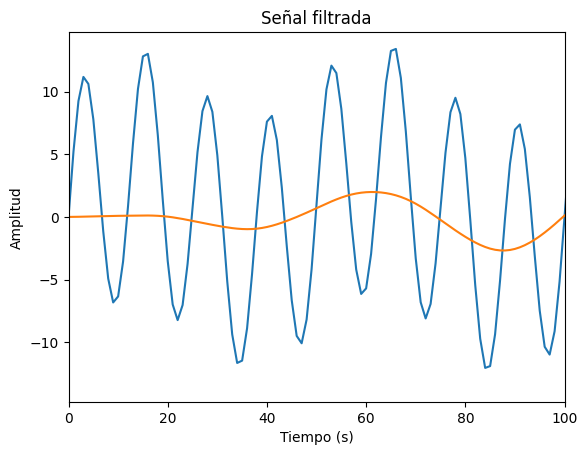

In [ ]:
#actividad 1
fs = 1000
f1_band = 15 # Changed variable name to avoid conflict with f1 used for x1
f2_band = 30 # Changed variable name to avoid conflict with f2 used for x2
n = np.arange(1000) #muestra de 0 - 1000
Ts = 1/fs
t = n*Ts

A1 = 1
f1 = 5
w1 = 2*np.pi*f1
phi1 = 0

#señal sinusoidal
x1 = A1*np.sin(w1*t + phi1)


A2 = 3
f2 = 20
w2 = 2*np.pi*f2
phi2 = 0

#señal sinusoidal
x2 = A2*np.sin(w2*t + phi2)


A3 = 10
f3 = 80
w3 = 2*np.pi*f3
phi3 = 0

#señal sinusoidal
x3 = A3*np.sin(w3*t + phi3)

xtotal = x1+x2+x3
plt.plot(n,xtotal)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal senoidal")
plt.xlim(0,100)

# Define N as the filter order, for example, 101
N = 101
fir = firwin(N, [f1_band,f2_band],pass_zero=False,fs=fs)
filtered = lfilter(fir, 1.0, xtotal)
plt.plot(n,filtered)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal filtrada")
plt.xlim(0,100)



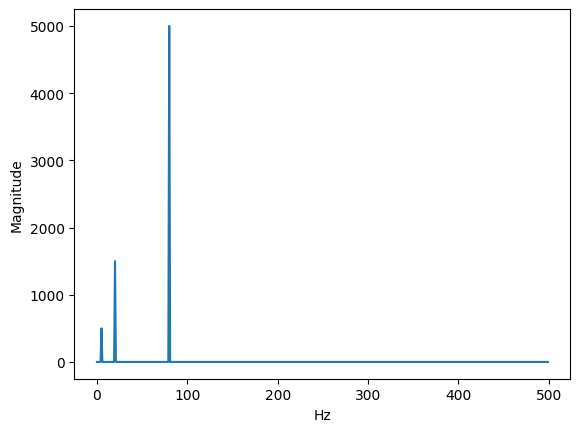

In [ ]:
X = np.fft.fft(xtotal)
freqs = np.fft.fftfreq(len(xtotal), 1/fs)

plt.plot(freqs[:len(xtotal)//2], np.abs(X[:len(xtotal)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

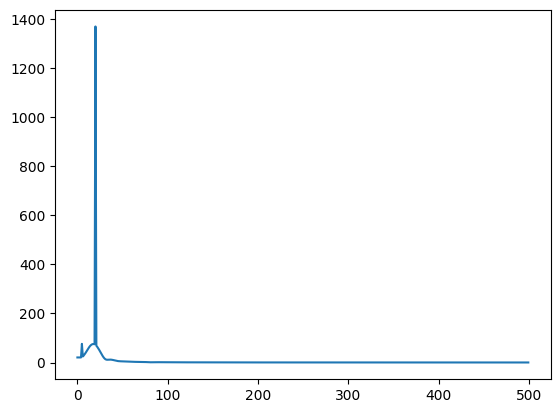

In [ ]:
X_filtered = np.fft.fft(filtered)
freqs_filtered = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs_filtered[:len(filtered)//2], np.abs(X_filtered[:len(filtered)//2]))

In [2]:
#Actividad 2
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.4 MB/s eta 0:00:00


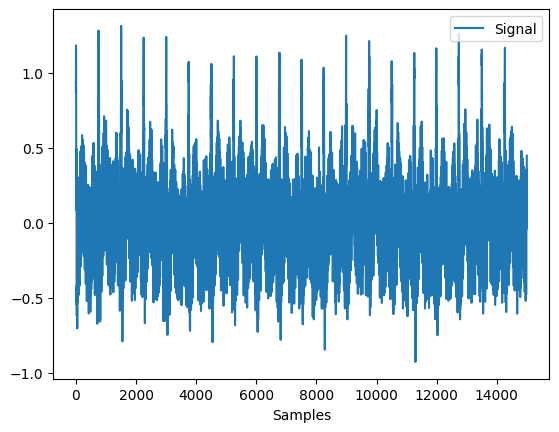

In [3]:
fs = 1000
duracion = 15
t = np.linspace(0, duracion, int(duracion * fs), endpoint=False)

ecg_limpio = nk.ecg_simulate(duration=duracion, sampling_rate=fs, noise=0,heart_rate=80)
ruido = np.random.normal(0,0.1,len(t))
interferencia = 0.25*np.sin(2*np.pi*60*t)
ecg_final = ecg_limpio + ruido + interferencia

nk.signal_plot(ecg_final)

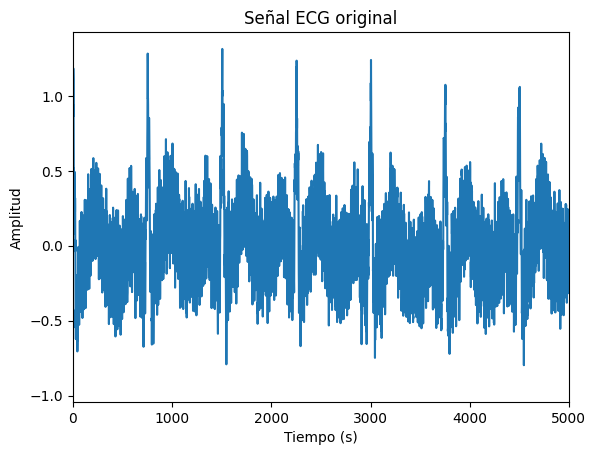

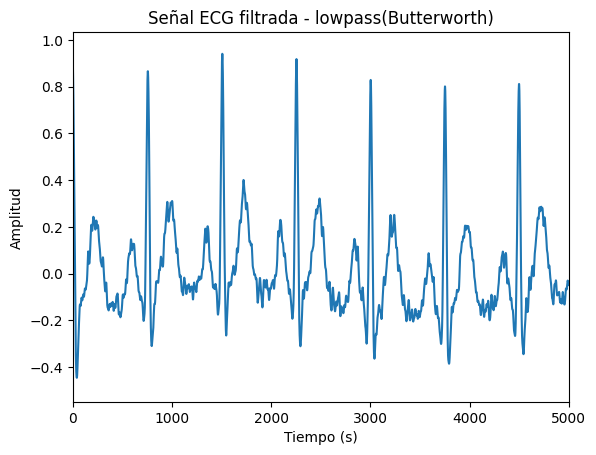

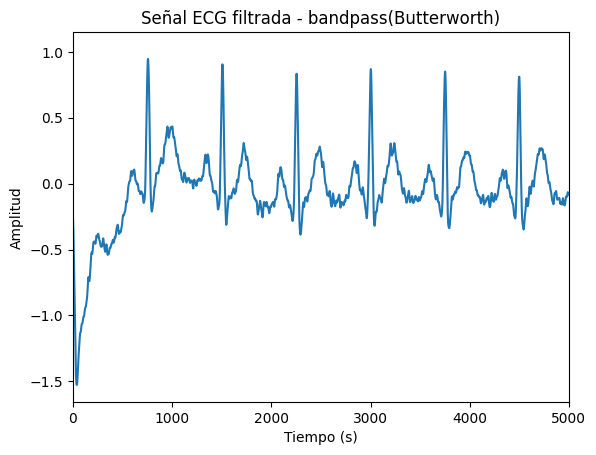

In [4]:

b, a = butter(4, 40, btype='lowpass', fs=fs)
filtered_ecg_low = filtfilt(b, a, ecg_final)


b, a = butter(4, [0.5,40], btype='bandpass', fs=fs)
filtered_ecg_band = filtfilt(b, a, ecg_final)

plt.plot(ecg_final)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG original")
plt.xlim(0,5000)
plt.show()



plt.figure()
plt.plot(filtered_ecg_low)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG filtrada - lowpass(Butterworth)")
plt.xlim(0,5000)
plt.show()

plt.figure()
plt.plot(filtered_ecg_band)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG filtrada - bandpass(Butterworth)")
plt.xlim(0,5000)
plt.show()

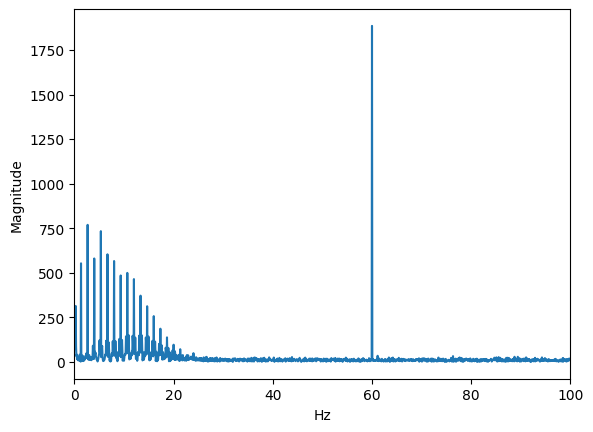

In [5]:
X = np.fft.fft(ecg_final)
freqs = np.fft.fftfreq(len(ecg_final), 1/fs)

plt.plot(freqs[:len(ecg_final)//2], np.abs(X[:len(ecg_final)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.xlim(0,100)
plt.show()

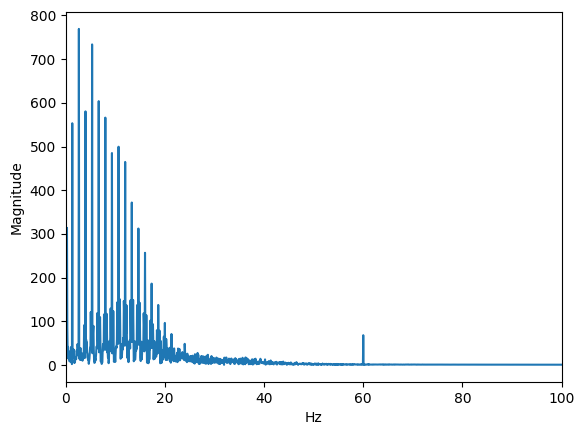

In [6]:
X = np.fft.fft(filtered_ecg_low)
freqs = np.fft.fftfreq(len(filtered_ecg_low), 1/fs)

plt.plot(freqs[:len(filtered_ecg_low)//2], np.abs(X[:len(filtered_ecg_low)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.xlim(0,100)
plt.show()

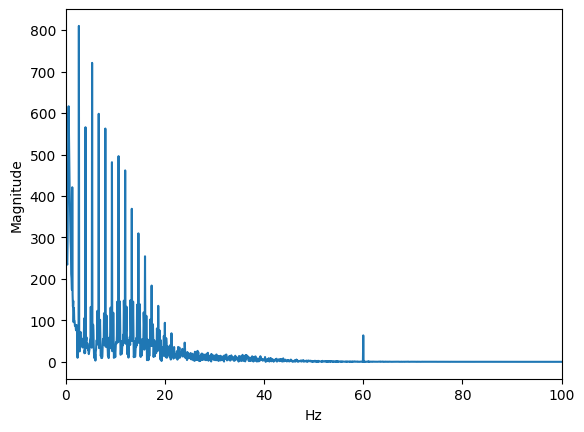

In [7]:
X = np.fft.fft(filtered_ecg_band)
freqs = np.fft.fftfreq(len(filtered_ecg_band), 1/fs)

plt.plot(freqs[:len(filtered_ecg_band)//2], np.abs(X[:len(filtered_ecg_band)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.xlim(0,100)
plt.show()

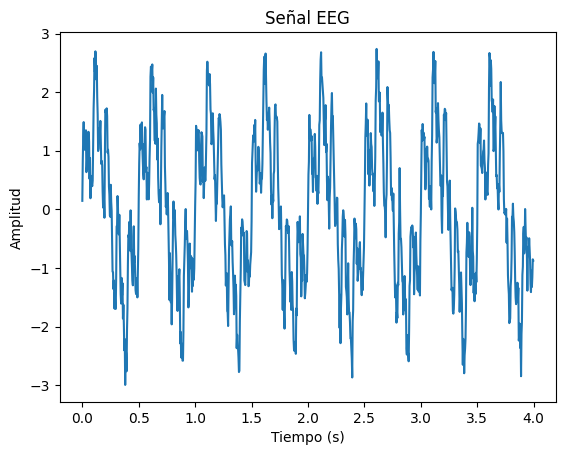

In [10]:
#actividad 3
fs = 250
duracion = 4
t = np.linspace(0, duracion, int(duracion * fs), endpoint=False)

onda_delta = 1.5 * np.sin(2 * np.pi * 2 * t)
onda_alfa = 0.8 * np.sin(2 * np.pi * 10 * t)
onda_beta = 0.5 * np.sin(2 * np.pi * 20 * t)
onda_gamma = 0.2 * np.sin(2 * np.pi * 40 * t)
ruido = np.random.normal(0,0.2,len(t))

eeg_total = onda_delta + onda_alfa + onda_beta + onda_gamma + ruido

plt.plot(t, eeg_total)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal EEG")
plt.show()

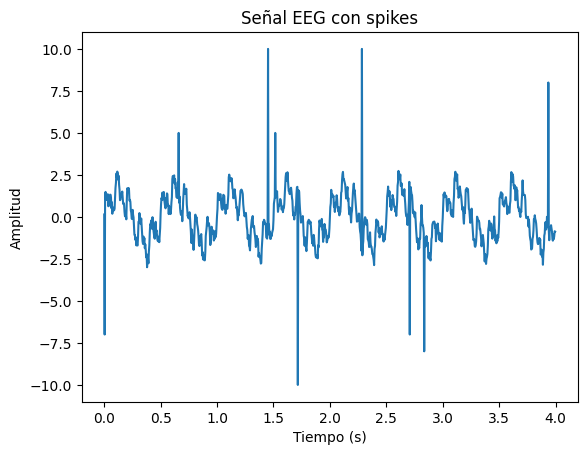

In [13]:
eeg_con_spikes = eeg_total.copy()
indices_spikes = np.random.choice(len(t),10,replace=False)
valor_spikes = np.random.choice([5, 6, 7, 8, 9, 10], size=10)
for idx in range(1,10):
    signo = np.random.choice([-1,1])
    eeg_con_spikes[indices_spikes[idx]] = signo*valor_spikes[idx]

plt.plot(t, eeg_con_spikes)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal EEG con spikes")
plt.show()

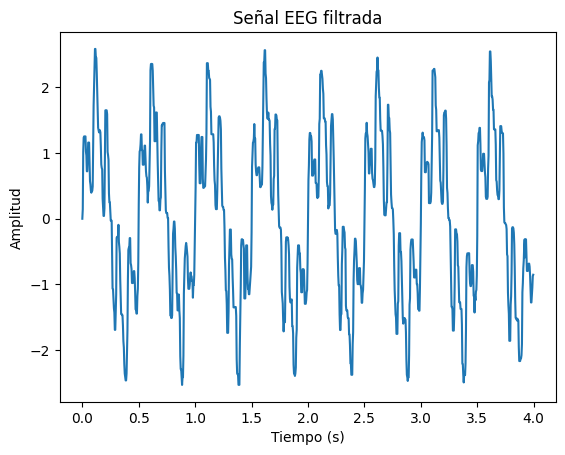

In [19]:
eeg_mediana = medfilt(eeg_con_spikes, 5)
plt.plot(t, eeg_mediana)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal EEG filtrada")
plt.show()

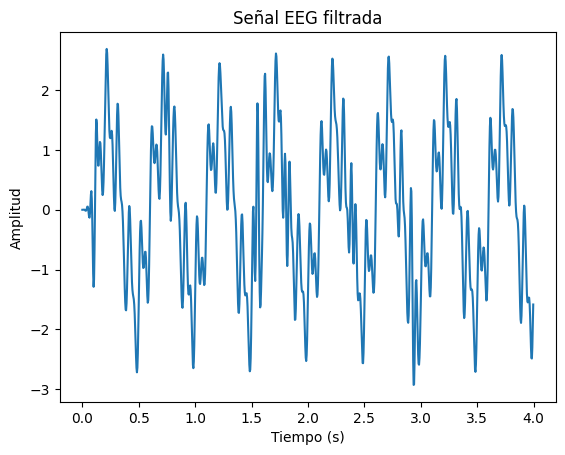

In [20]:
b = firwin(51, 30, fs = fs, window = 'hann',pass_zero="lowpass")
eeg_filt = lfilter(b, 1, eeg_con_spikes)
plt.plot(t, eeg_filt)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal EEG filtrada")
plt.show()


In [ ]:
#es mejor el filtro de mediana
#el filtro FIR lowpass no descarta todos los spikes, ya que estos presentan frecuencias variadas
# en cambio, el filtro de mediana toma el valor intermedio de una ventana de datos, es decir, no toma en cuenta valores extremos como los spikes


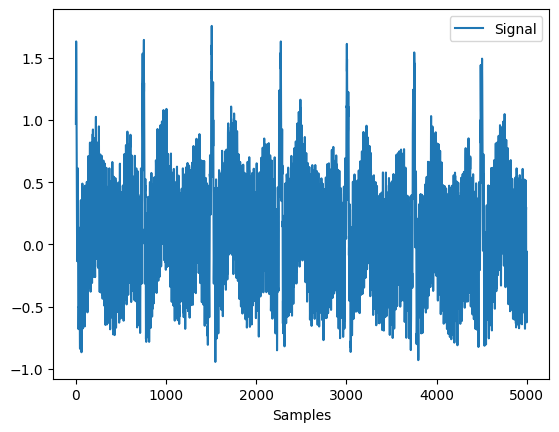

In [3]:
#actividad 4
fs = 1000
duracion = 5
t = np.linspace(0, duracion, int(duracion * fs), endpoint=False)
ecg_limpio = nk.ecg_simulate(duration=duracion, sampling_rate=fs, noise=0,heart_rate=80)
ruido_blanco = np.random.normal(0,0.1,len(t))
ruido_60hz = 0.5*np.sin(2*np.pi*60*t)
ecg_final = ecg_limpio + ruido_blanco + ruido_60hz

nk.signal_plot(ecg_final)

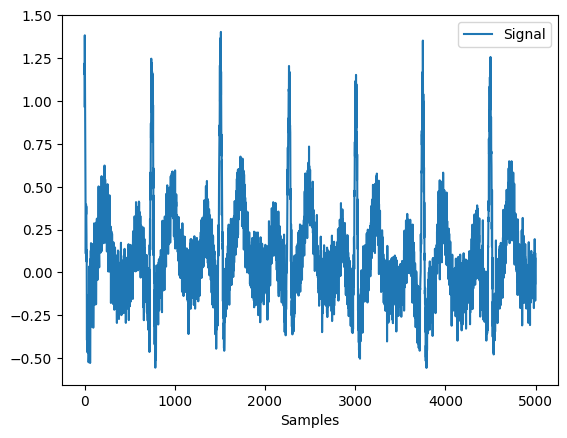

In [4]:
b_notch, a_notch = iirnotch(60, 30, fs)
ecg_notch = filtfilt(b_notch, a_notch, ecg_final)
nk.signal_plot(ecg_notch)

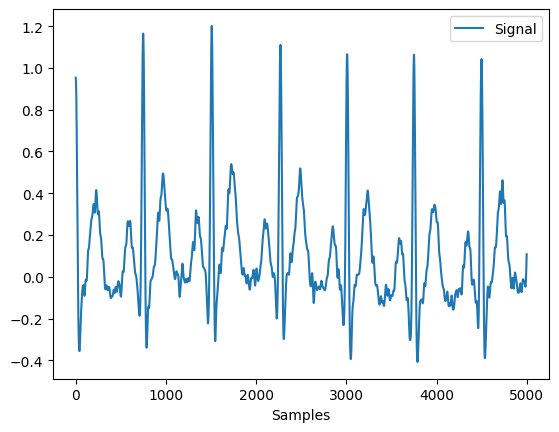

In [6]:
b_low, a_low = butter(4, 40, btype='lowpass', fs=fs)
ecg_low = filtfilt(b_low, a_low, ecg_notch)
nk.signal_plot(ecg_low)

In [7]:
#actividad 5
from scipy.signal import correlate

In [12]:
fs = 1000
duracion = 10
t = np.linspace(0, duracion, int(duracion * fs), endpoint=False)
n_muestras = len(t)

ecg_ref = nk.ecg_simulate(duration=duracion, sampling_rate=fs, noise=0,heart_rate=80)
resp_ref = nk.rsp_simulate(duration = duracion, sampling_rate=fs, respiratory_rate=15)

accel_ref = np.sin(2*np.pi*1*t)

delay_ecg = int(0.5*fs)
delay_resp = int(1.2*fs)
delay_accel = int(2.0*fs)

ecg_desync = np.roll(ecg_ref, delay_ecg) + np.random.normal(0,0.1,n_muestras)
resp_desync = np.roll(resp_ref, delay_resp) + np.random.normal(0,0.05,n_muestras)
accel_desync = np.roll(accel_ref, delay_accel) + np.random.normal(0,0.2,n_muestras)

corr1 = correlate(ecg_ref, ecg_desync)
corr2 = correlate(resp_ref, resp_desync)
corr3 = correlate(accel_ref, accel_desync)

retraso1 = np.argmax(corr1) - len(ecg_ref)
retraso2 = np.argmax(corr2) - len(resp_ref)
retraso3 = np.argmax(corr3) - len(accel_ref)

ecg_sync = np.roll(ecg_desync, -retraso1)
resp_sync = np.roll(resp_desync, -retraso2)
accel_sync = np.roll(accel_desync, -retraso3)




In [13]:
#actividad 6
from scipy.signal import resample

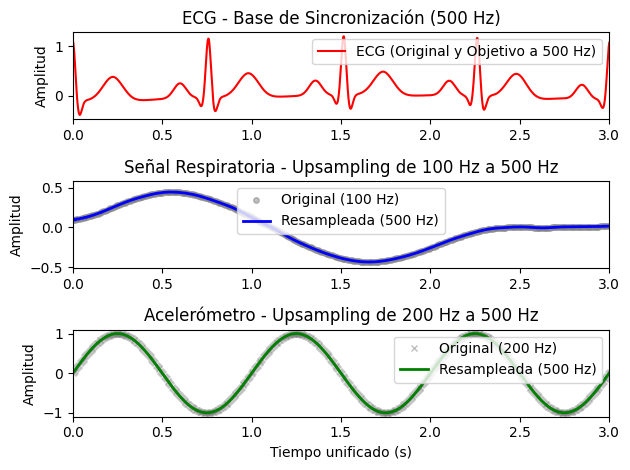

In [18]:
duracion = 10
fs_ecg = 500
fs_resp = 100
fs_acc = 200

t_ecg = np.linspace (0,duracion, int(fs_ecg*duracion), endpoint=False)
t_resp = np.linspace (0,duracion, int(fs_resp*duracion), endpoint=False)
t_acc = np.linspace (0,duracion, int(fs_acc*duracion), endpoint=False)

ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs_ecg, heart_rate=80)
resp = nk.rsp_simulate(duration = duracion, sampling_rate=fs_resp, respiratory_rate=15)
accel = np.sin(2*np.pi*1*t_acc)

muestras_ref = len(ecg)

ecg_resampled = ecg
resp_resampled = resample(resp, muestras_ref)
accel_resampled = resample(accel, muestras_ref)

t_resampled = t_ecg

plt.figure()


plt.subplot(3, 1, 1)
plt.plot(t_resampled, ecg_resampled, color='red', label='ECG (Original y Objetivo a 500 Hz)')
plt.title("ECG - Base de Sincronización (500 Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 3)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_resp, resp, 'o', color='gray', alpha=0.5, markersize=4, label='Original (100 Hz)')
plt.plot(t_resampled, resp_resampled, color='blue', linewidth=2, label='Resampleada (500 Hz)')
plt.title("Señal Respiratoria - Upsampling de 100 Hz a 500 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 3)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_acc, accel, 'x', color='gray', alpha=0.5, markersize=4, label='Original (200 Hz)')
plt.plot(t_resampled, accel_resampled, color='green', linewidth=2, label='Resampleada (500 Hz)')
plt.title("Acelerómetro - Upsampling de 200 Hz a 500 Hz")
plt.xlabel("Tiempo unificado (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 3)
plt.legend()

plt.tight_layout()
plt.show()